# Child Growth Status Prediction Model Training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Philimuhire/child-growth-project/blob/master/model/notebooks/train_model.ipynb)

This notebook trains an **XGBoost classifier** to predict child nutritional status using data from the **Rwanda Demographic and Health Survey (RDHS)** dataset.

The model classifies children into one of five nutritional categories:
- **Normal** - adequate nutritional status
- **Stunted** - low height-for-age (chronic malnutrition)
- **Wasted** - low weight-for-height (acute malnutrition)
- **Underweight** - low weight-for-age
- **Overweight** - high BMI-for-age

WHO Z-scores are computed from anthropometric measurements and used alongside socioeconomic features to train the classifier.

## Running on Google Colab

1. Click the **Open in Colab** badge above.
2. Run the first code cell — it installs any missing packages.
3. When the data-loading cell prompts, **upload your own DHS Individual Recode (IR) `.xlsx` file**.

The notebook auto-detects whether it's running on Colab or locally and adapts the data loading and artifact-saving paths accordingly.

In [12]:
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    %pip install -q xgboost lightgbm openpyxl imbalanced-learn

In [13]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

print('All libraries imported successfully.')


All libraries imported successfully.


## 1. Load and Explore Dataset

The dataset comes from the **Rwanda Demographic and Health Survey (RDHS) 2019-2020 Individual Recode (IR) file**. DHS uses standardized variable codes across all surveys worldwide. The columns we use:

| DHS Code | Meaning | Stored As |
|---|---|---|
| `caseid`, `bidx` | Identifiers (household + child index) | string / int |
| `hw1` | Child's age in months | int (0-59) |
| `b4` | Child's sex | "male" / "female" |
| `hw2` | Child's weight | kg × 10 (divide by 10) |
| `hw3` | Child's height | cm × 10 (divide by 10) |
| `hw70` | Height-for-Age Z-score (HAZ) | × 100 (divide by 100) |
| `hw71` | Weight-for-Age Z-score (WAZ) | × 100 (divide by 100) |
| `hw72` | Weight-for-Height Z-score (WHZ) | × 100 (divide by 100) |
| `hw73` | BMI-for-Age Z-score (BAZ) | × 100 (divide by 100) |
| `v190` | Household wealth quintile | poorest / poorer / middle / richer / richest |
| `v106` | Mother's highest education level | none / primary / secondary / higher |
| `v025` | Residence type | urban / rural |
| `v024` | Province / region | kigali / north / south / east / west |
| `sdistrict` | District (Rwanda-specific) | 30 districts |
| `v116` | Sanitation facility | various — collapsed to improved / unimproved / open_defecation |
| `v113` | Drinking water source | various — collapsed to improved / unimproved |
| `v404` | Currently breastfeeding | yes / no |

The DHS multiplies decimal values by 10 or 100 to store them as integers; the code below reverses this. The full DHS Recode Manual is at https://dhsprogram.com/publications/publication-dhsg4-dhs-questionnaires-and-manuals.cfm


In [14]:
# Load the RDHS dataset (IR file)

import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import files
    print("Upload the DHS Individual Recode (IR) .xlsx file.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No file was uploaded.")
    ir_path = next(iter(uploaded.keys()))
else:
    ir_path = '../data/dataset for ML.xlsx'
    if not os.path.exists(ir_path):
        raise FileNotFoundError(
            f"RDHS dataset not found. Place the file at: {ir_path}"
        )

print(f"Dataset found: {ir_path}")

# Only load the columns we need from the IR file (memory efficient)
ir_cols = ['caseid','bidx','hw1','b4','hw2','hw3','hw70','hw71','hw72','hw73',
           'v190','v106','v025','v024','sdistrict','v116','v113','v404']
ir_available = pd.read_excel(ir_path, engine='openpyxl', nrows=0).columns.tolist()
ir_cols = [c for c in ir_cols if c in ir_available]

raw = pd.read_excel(ir_path, engine='openpyxl', usecols=ir_cols)
print(f"  IR raw shape: {raw.shape}")

# Filter to children with anthropometric measurements
raw = raw[raw['hw1'].notna()].copy()
print(f"  Children with measurements (hw1 not null): {len(raw)}")

# Convert numeric columns
for c in ['hw2','hw3','hw70','hw71','hw72','hw73']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

# Build the canonical dataframe
data = pd.DataFrame()
data['age_months'] = raw['hw1'].astype(int)
data['sex']        = raw['b4'].str.strip().str.lower()
data['weight_kg']  = raw['hw2'] / 10.0
data['height_cm']  = raw['hw3'] / 10.0

# Precomputed DHS Z-scores (stored ×100)
data['haz'] = raw['hw70'] / 100.0
data['waz'] = raw['hw71'] / 100.0
data['whz'] = raw['hw72'] / 100.0
data['baz'] = raw['hw73'] / 100.0

# Demographics
data['wealth_index'] = raw['v190'].str.strip().str.lower()
edu_map = {
    'no educa':'none', 'no educat':'none', 'no education':'none',
    'primary':'primary',
    'secondar':'secondary', 'secondary':'secondary',
    'higher':'higher',
}
data['mothers_education'] = raw['v106'].str.strip().str.lower().map(edu_map).fillna('none')
data['residence_type']    = raw['v025'].str.strip().str.lower()
data['region']            = raw['v024'].str.strip().str.lower() if 'v024' in raw.columns else 'unknown'
data['district']          = raw['sdistrict'].str.strip().str.lower() if 'sdistrict' in raw.columns else 'unknown'

def map_sanitation(v):
    v = str(v).strip().lower()
    if v.startswith(('flush','pit latr','ventilat','composti')): return 'improved'
    if v.startswith('no facil') or v.startswith('open') or v == 'bush': return 'open_defecation'
    return 'unimproved'
data['sanitation_type'] = raw['v116'].apply(map_sanitation)

def map_water(v):
    v = str(v).strip().lower()
    for p in ('piped','public t','tube wel','protecte','bottled','rainwate'):
        if v.startswith(p): return 'improved'
    return 'unimproved'
data['water_source'] = raw['v113'].apply(map_water)

# Contextual: currently breastfeeding
if 'v404' in raw.columns:
    bf = raw['v404'].astype(str).str.strip().str.lower()
    data['currently_breastfeeding'] = bf.map({'yes':'yes','no':'no'}).fillna('no')
else:
    data['currently_breastfeeding'] = 'no'

# Drop rows with missing anthropometry / Z-scores
before = len(data)
data = data.dropna(subset=['haz','waz','whz','baz','weight_kg','height_cm']).reset_index(drop=True)
print(f"  After dropping missing: {len(data)} rows (removed {before - len(data)})")

# Clamp Z-scores to WHO convention
for c in ['haz','waz','whz','baz']:
    data[c] = data[c].clip(-6, 6)

print(f"\nFinal dataset shape: {data.shape}")
print(f"\nFirst 5 rows:")
display(data.head())
print(f"\nNull counts:")
print(data.isnull().sum())
print(f"\nCategorical value counts:")
for c in ['sex','wealth_index','mothers_education','residence_type',
          'region','sanitation_type','water_source','currently_breastfeeding']:
    if c in data.columns:
        print(f"  {c}: {dict(data[c].value_counts())}")
print(f"  district: {data['district'].nunique()} unique values (sample: {list(data['district'].unique()[:5])})")


Dataset found: ../data/dataset for ML.xlsx
  IR raw shape: (8092, 18)
  Children with measurements (hw1 not null): 3821
  After dropping missing: 3803 rows (removed 18)

Final dataset shape: (3803, 16)

First 5 rows:


,age_months,sex,weight_kg,height_cm,haz,waz,whz,baz,wealth_index,mothers_education,residence_type,region,district,sanitation_type,water_source,currently_breastfeeding
0,37,male,12.4,89.1,-2.17,-1.38,-0.27,0.06,richer,secondary,rural,kigali,gasabo,improved,improved,no
1,10,female,10.8,69.7,-0.90,1.86,3.00,3.18,richest,secondary,rural,kigali,gasabo,improved,improved,yes
2,53,female,18.2,100.4,-1.20,0.45,1.82,1.70,richest,secondary,rural,kigali,gasabo,improved,improved,yes
3,59,female,14.2,102.9,-1.35,-1.74,-1.40,-1.38,richest,higher,rural,kigali,gasabo,improved,improved,no
4,32,female,10.7,82.8,-2.75,-1.76,-0.16,0.11,richest,primary,rural,kigali,gasabo,improved,improved,no



Null counts:
age_months                 0
sex                        0
weight_kg                  0
height_cm                  0
haz                        0
waz                        0
whz                        0
baz                        0
wealth_index               0
mothers_education          0
residence_type             0
region                     0
district                   0
sanitation_type            0
water_source               0
currently_breastfeeding    0
dtype: int64

Categorical value counts:
  sex: {'male': np.int64(1917), 'female': np.int64(1886)}
  wealth_index: {'poorest': np.int64(915), 'poorer': np.int64(780), 'middle': np.int64(712), 'richer': np.int64(705), 'richest': np.int64(691)}
  mothers_education: {'primary': np.int64(2480), 'secondary': np.int64(695), 'none': np.int64(452), 'higher': np.int64(176)}
  residence_type: {'rural': np.int64(3016), 'urban': np.int64(787)}
  region: {'west': np.int64(973), 'east': np.int64(917), 'south': np.int64(875), 'north

## 2. Z-Scores (Precomputed by DHS)

The four WHO Z-scores (WAZ, HAZ, WHZ, BAZ) come precomputed from the DHS dataset (`hw70`-`hw73`, divided by 100). This section inspects their distributions to confirm the data looks healthy before using them as model features and to derive the target labels in the next section.


Z-score summary:


,waz,haz,whz,baz
count,3803.000000,3803.000000,3803.000000,3803.000000
mean,-0.579540,-1.512984,0.400126,0.535693
std,1.008609,1.166522,1.005579,1.020109
min,-5.410000,-5.900000,-4.660000,-4.750000
25%,-1.220000,-2.280000,-0.250000,-0.120000
50%,-0.570000,-1.540000,0.380000,0.530000
75%,0.050000,-0.740000,1.055000,1.185000
max,3.360000,3.950000,4.300000,4.440000


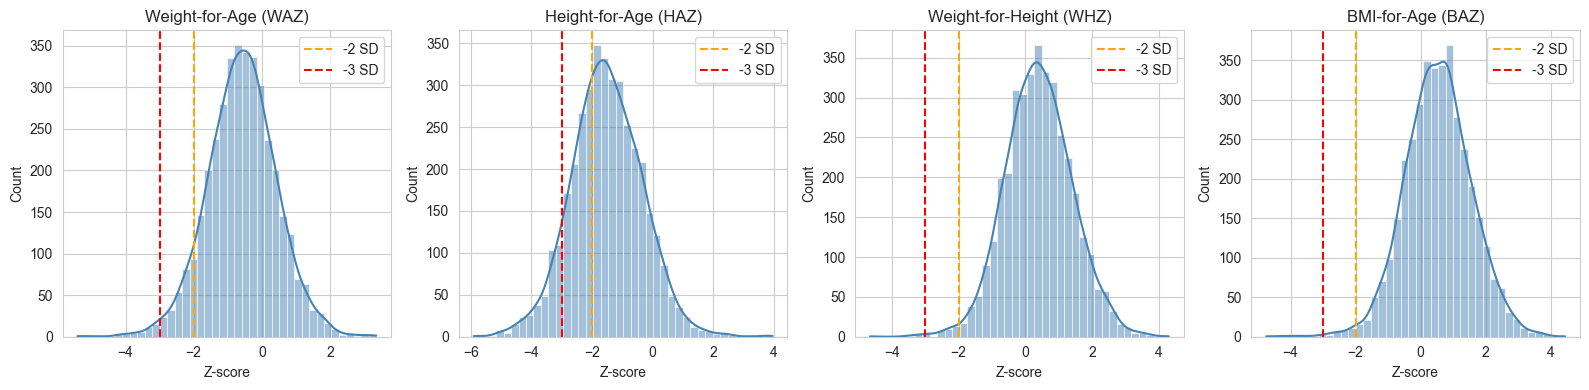

In [15]:
print("Z-score summary:")
display(data[['waz', 'haz', 'whz', 'baz']].describe())

# Visualize Z-score distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title in zip(axes, ['waz', 'haz', 'whz', 'baz'],
                            ['Weight-for-Age', 'Height-for-Age', 'Weight-for-Height', 'BMI-for-Age']):
    sns.histplot(data[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.axvline(-2, color='orange', linestyle='--', label='-2 SD')
    ax.axvline(-3, color='red', linestyle='--', label='-3 SD')
    ax.set_title(f'{title} ({col.upper()})')
    ax.set_xlabel('Z-score')
    ax.legend()
plt.tight_layout()
plt.show()


## 3. Create Target Labels

Convert the four Z-scores into a single nutritional status label per child using WHO thresholds with a priority order (wasted > underweight > stunted > overweight > normal). The model will be trained to predict this single class.


Nutritional Status Distribution:
status
normal         2331
stunted        1013
underweight     252
overweight      165
wasted           42
Name: count, dtype: int64

Percentages:
status
normal         61.29
stunted        26.64
underweight     6.63
overweight      4.34
wasted          1.10
Name: proportion, dtype: float64


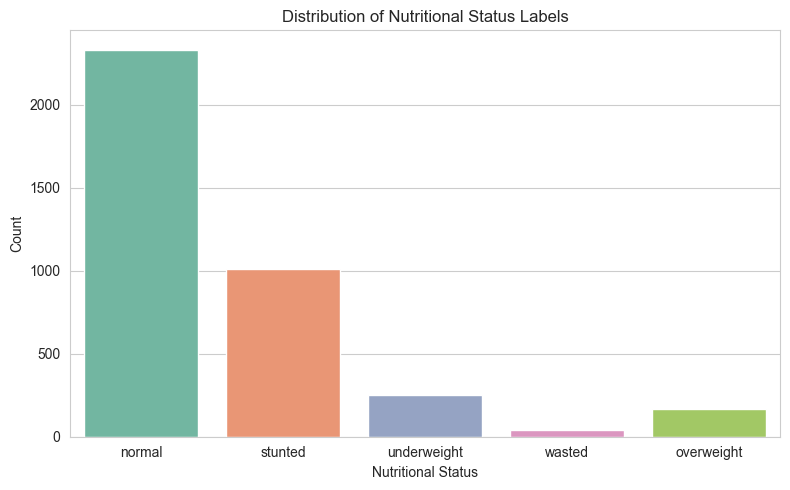

In [16]:
# Assign a single nutritional status label using WHO thresholds
# Priority order: wasted > underweight > stunted > overweight > normal
def classify_status(row):
    if row['whz'] < -2:
        return 'wasted'
    elif row['waz'] < -2:
        return 'underweight'
    elif row['haz'] < -2:
        return 'stunted'
    elif row['baz'] > 2:
        return 'overweight'
    else:
        return 'normal'


# Apply the function to every row
data['status'] = data.apply(classify_status, axis=1)

# Show class distribution
print("Nutritional Status Distribution:")
print(data['status'].value_counts())
print(f"\nPercentages:")
print(data['status'].value_counts(normalize=True).round(4) * 100)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
order = ['normal', 'stunted', 'underweight', 'wasted', 'overweight']
sns.countplot(data=data, x='status', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Nutritional Status Labels')
ax.set_xlabel('Nutritional Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. Feature Engineering and Encoding

Convert all categorical variables (sex, wealth quintile, region, district, etc.) into integer codes the model can consume, then scale the resulting feature matrix so every column has zero mean and unit variance. The encoding maps are saved to disk so the backend uses identical encoding at inference time.


In [17]:
# Categorical encoding maps (kept in sync with backend/app/services/ml_service.py)
CATEGORICAL_ENCODINGS = {
    'sex': {'male': 0, 'female': 1},
    'wealth_index': {'poorest': 0, 'poorer': 1, 'middle': 2, 'richer': 3, 'richest': 4},
    'mothers_education': {'none': 0, 'primary': 1, 'secondary': 2, 'higher': 3},
    'residence_type': {'urban': 0, 'rural': 1},
    'region': {'kigali': 0, 'south': 1, 'north': 2, 'east': 3, 'west': 4},
    'sanitation_type': {'improved': 0, 'unimproved': 1, 'open_defecation': 2},
    'water_source': {'improved': 0, 'unimproved': 1},
    'currently_breastfeeding': {'yes': 1, 'no': 0},
}

# District has 30 categories (Rwandan districts). Build a stable label-encoded map
# from the distinct values present in the training data, alphabetically ordered.
DISTRICT_ENCODING = {d: i for i, d in enumerate(sorted(data['district'].dropna().unique()))}
CATEGORICAL_ENCODINGS['district'] = DISTRICT_ENCODING
print(f"District encoding: {len(DISTRICT_ENCODING)} unique districts")

# Apply categorical encodings
for col, mapping in CATEGORICAL_ENCODINGS.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)

# Drop rows where encoding produced NaN (unexpected category)
before = len(data)
data = data.dropna(subset=list(CATEGORICAL_ENCODINGS.keys()))
if len(data) < before:
    print(f"Dropped {before - len(data)} rows with unmapped categorical values")

# 16 total features (4 anthropometric + 7 demographic/geo + 1 contextual + 4 Z-scores)
FEATURE_COLUMNS = [
    # Anthropometric
    'age_months', 'sex', 'weight_kg', 'height_cm',
    # Demographic / socioeconomic / geographic
    'wealth_index', 'mothers_education', 'residence_type',
    'region', 'district',
    'sanitation_type', 'water_source',
    # Contextual
    'currently_breastfeeding',
    # Derived WHO Z-scores
    'waz', 'haz', 'whz', 'baz',
]

# Prepare features and target
X = data[FEATURE_COLUMNS].copy()
y = data['status'].copy()

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Number of features: {len(FEATURE_COLUMNS)}")
print(f"Features: {FEATURE_COLUMNS}")
print(f"Classes: {list(label_encoder.classes_)}")


District encoding: 30 unique districts
Class mapping: {'normal': np.int64(0), 'overweight': np.int64(1), 'stunted': np.int64(2), 'underweight': np.int64(3), 'wasted': np.int64(4)}

Feature matrix shape: (3803, 16)
Number of features: 16
Features: ['age_months', 'sex', 'weight_kg', 'height_cm', 'wealth_index', 'mothers_education', 'residence_type', 'region', 'district', 'sanitation_type', 'water_source', 'currently_breastfeeding', 'waz', 'haz', 'whz', 'baz']
Classes: ['normal', 'overweight', 'stunted', 'underweight', 'wasted']


## 5. Train/Test Split

Split the dataset into 80% training and 20% test. The split is stratified on the target class so rare categories (e.g. wasted) end up in both sides — without this, the test set might contain none of them.


In [18]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nTraining class distribution:")
for cls, name in enumerate(label_encoder.classes_):
    count = (y_train == cls).sum()
    print(f"  {name:12s}: {count} ({count/len(y_train)*100:.1f}%)")


Training set size: 3042
Test set size:     761

Training class distribution:
  normal      : 1864 (61.3%)
  overweight  : 132 (4.3%)
  stunted     : 810 (26.6%)
  underweight : 202 (6.6%)
  wasted      : 34 (1.1%)


## 6. Handle Class Imbalance

The dataset is dominated by "normal" children (~61%) while "wasted" is ~1%. Without rebalancing, the model would just predict "normal" everywhere. We compute inverse-frequency sample weights so each class contributes roughly equally to the training loss.


In [19]:
# Compute inverse-frequency sample weights to handle class imbalance
from collections import Counter

class_counts = Counter(y_train)
total = len(y_train)
sample_weights = np.array(
    [total / (len(class_counts) * class_counts[y]) for y in y_train]
)

print("Class weights (inverse frequency):")
for cls in sorted(class_counts.keys()):
    weight = total / (len(class_counts) * class_counts[cls])
    print(f"  {label_encoder.classes_[cls]:12s}: {weight:.4f}")

# SMOTE alternative (commented out):
# from imblearn.over_sampling import SMOTE
# X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)


Class weights (inverse frequency):
  normal      : 0.3264
  overweight  : 4.6091
  stunted     : 0.7511
  underweight : 3.0119
  wasted      : 17.8941


## 7. Model Training, Comparison, and Selection

Train three tree-based models on the same train/test split, compare them on the same metrics, and pick the production model.

### Models compared

| Model | Family | Library |
|---|---|---|
| **LightGBM** | Gradient boosting | `lightgbm` (Microsoft) |
| **Random Forest** | Bagging ensemble | `sklearn.ensemble` |
| **XGBoost** | Gradient boosting | `xgboost` |

### Metrics collected per model

| Variable | Metric | Meaning |
|---|---|---|
| `acc` | Accuracy | Fraction of predictions that exactly match the true label |
| `f1_macro` | Macro F1 | Average per-class F1, treating each class equally — fair to rare classes |
| `f1_weighted` | Weighted F1 | Average per-class F1, weighted by class size |
| `auc` | ROC-AUC | How well the model ranks correct examples above incorrect ones (One-vs-Rest) |
| `f1_per_class` | Per-class F1 | F1 broken down per nutritional status |
| `train_time` | Training time (s) | Time to fit the model |

### Selection criterion

The winner is selected by **Macro F1** (treats each class equally, robust to imbalance). **ROC-AUC** is used as the tiebreaker.



Training LightGBM...
Accuracy:    0.9921
Macro F1:    0.9545
Weighted F1: 0.9926
ROC-AUC:     1.0000
Train time:  0.05s

Training Random Forest...
Accuracy:    0.9842
Macro F1:    0.9634
Weighted F1: 0.9852
ROC-AUC:     1.0000
Train time:  0.03s

Training XGBoost...
Accuracy:    0.9974
Macro F1:    0.9840
Weighted F1: 0.9974
ROC-AUC:     1.0000
Train time:  4.68s

OVERALL COMPARISON


,Accuracy,Macro F1,Weighted F1,ROC-AUC,Train Time (s)
Model,,,,,
LightGBM,0.9921,0.9545,0.9926,1.0,0.05
Random Forest,0.9842,0.9634,0.9852,1.0,0.03
XGBoost,0.9974,0.9840,0.9974,1.0,4.68



PER-CLASS F1 SCORE


,normal,overweight,stunted,underweight,wasted
Model,,,,,
LightGBM,0.995,1.000,0.998,0.98,0.800
Random Forest,0.999,0.846,0.972,1.00,1.000
XGBoost,0.999,1.000,1.000,0.98,0.941


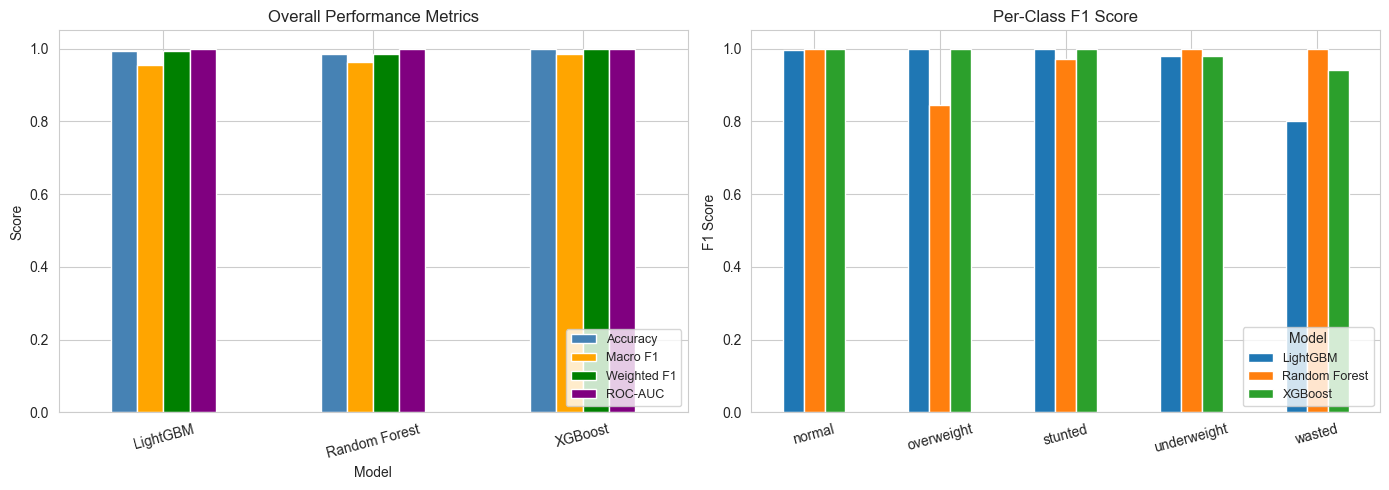


MODEL SELECTION
Selected model: XGBoost
  Macro F1:    0.9840
  Accuracy:    0.9974
  ROC-AUC:     1.0000
  Train time:  4.68s

Selection criterion: highest Macro F1, with ROC-AUC as tiebreaker.
'XGBoost' will be saved as the production artifact and served by
the FastAPI backend.

DETAILED EVALUATION: XGBoost

Classification report for XGBoost:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       467
  overweight       1.00      1.00      1.00        33
     stunted       1.00      1.00      1.00       203
 underweight       0.98      0.98      0.98        50
      wasted       0.89      1.00      0.94         8

    accuracy                           1.00       761
   macro avg       0.97      1.00      0.98       761
weighted avg       1.00      1.00      1.00       761



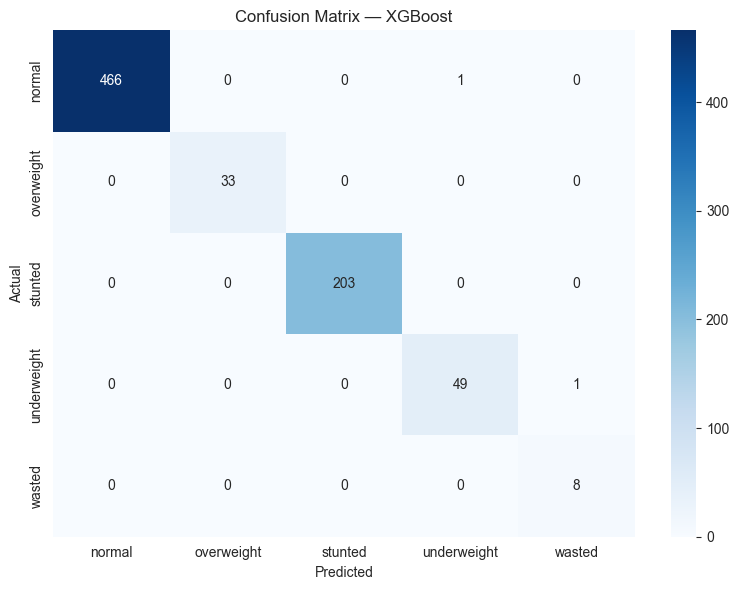

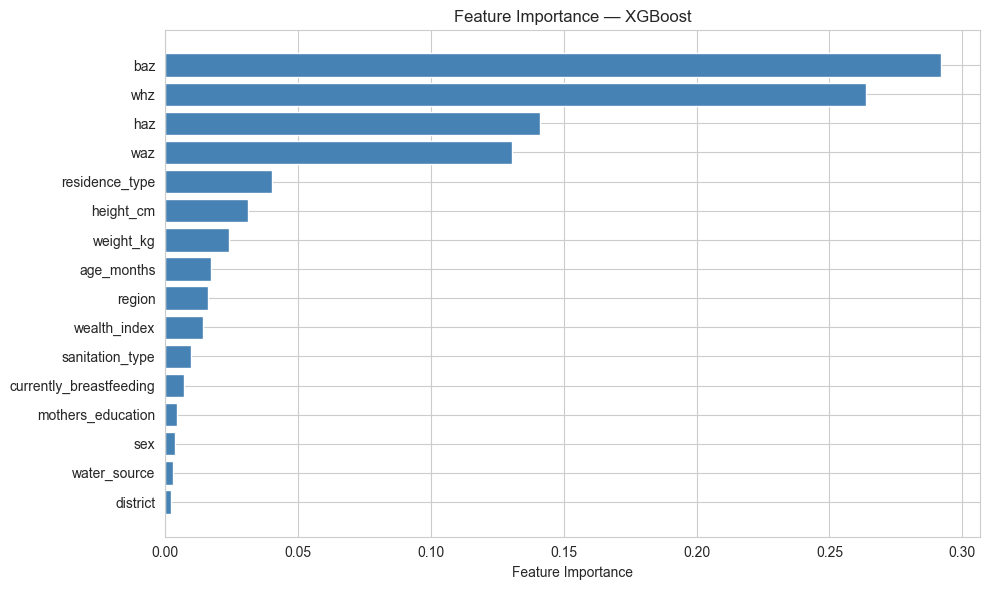

In [20]:
# Train and evaluate three candidate models on the same train/test split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
)
import lightgbm as lgb
import xgboost as xgb
import time

candidates = {
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=20, max_depth=3, num_leaves=4, learning_rate=0.05,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=10, max_depth=3, random_state=42, n_jobs=-1,
    ),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob', num_class=5, eval_metric='mlogloss',
        max_depth=6, learning_rate=0.1, n_estimators=300,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False,
    ),
}

# Train each candidate, collect metrics + the trained model
results = []
trained_models = {}

for name, mdl in candidates.items():
    print(f"\n{'='*70}")
    print(f"Training {name}...")
    print(f"{'='*70}")

    t0 = time.time()
    mdl.fit(X_train, y_train, sample_weight=sample_weights)
    train_time = time.time() - t0

    y_pred = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1': f1_macro,
        'Weighted F1': f1_weighted,
        'ROC-AUC': auc,
        'Train Time (s)': round(train_time, 2),
        'per_class_f1': f1_per_class,
    })
    trained_models[name] = mdl

    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"ROC-AUC:     {auc:.4f}")
    print(f"Train time:  {train_time:.2f}s")

# ---------- Comparison tables ----------
print("\n" + "="*70)
print("OVERALL COMPARISON")
print("="*70)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'per_class_f1'} for r in results
]).set_index('Model')
for col in ['Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']:
    results_df[col] = results_df[col].astype(float).round(4)
display(results_df)

print("\n" + "="*70)
print("PER-CLASS F1 SCORE")
print("="*70)
per_class_df = pd.DataFrame(
    [[r['Model']] + [round(v, 3) for v in r['per_class_f1']] for r in results],
    columns=['Model'] + list(label_encoder.classes_),
).set_index('Model')
display(per_class_df)

# ---------- Visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'orange', 'green', 'purple'],
)
axes[0].set_title('Overall Performance Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

per_class_df.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Per-Class F1 Score')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('')
axes[1].legend(title='Model', loc='lower right', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ---------- Pick the winner ----------
# Sort by Macro F1 (descending), then by ROC-AUC (descending) as tiebreaker.
sorted_results = sorted(
    results,
    key=lambda r: (-r['Macro F1'], -r['ROC-AUC']),
)
best = sorted_results[0]
best_name = best['Model']
model = trained_models[best_name]   # production model

print("\n" + "="*70)
print("MODEL SELECTION")
print("="*70)
print(f"Selected model: {best_name}")
print(f"  Macro F1:    {best['Macro F1']:.4f}")
print(f"  Accuracy:    {best['Accuracy']:.4f}")
print(f"  ROC-AUC:     {best['ROC-AUC']:.4f}")
print(f"  Train time:  {best['Train Time (s)']}s")
print()
print("Selection criterion: highest Macro F1, with ROC-AUC as tiebreaker.")
print(f"'{best_name}' will be saved as the production artifact and served by")
print("the FastAPI backend.")

# ---------- Detailed evaluation of the chosen model ----------
print("\n" + "="*70)
print(f"DETAILED EVALUATION: {best_name}")
print("="*70)

y_pred = model.predict(X_test)
y_probas = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report_dict = classification_report(
    y_test, y_pred, target_names=label_encoder.classes_, output_dict=True,
)

print(f"\nClassification report for {best_name}:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=ax,
)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'importance': importances,
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()


## 8. Save Model Artifacts

Persist the trained model and its preprocessing artifacts (scaler, label encoder, feature columns, district encodings) to disk. The same files are also copied to `backend/app/ml_artifacts/` so the FastAPI server picks them up on startup.


In [21]:
import os

artifacts_dir = '../artifacts' if not IN_COLAB else 'artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# Save model + preprocessing artifacts
joblib.dump(model, os.path.join(artifacts_dir, 'xgb_model.joblib'))
joblib.dump(label_encoder, os.path.join(artifacts_dir, 'label_encoder.joblib'))
joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))
joblib.dump(FEATURE_COLUMNS, os.path.join(artifacts_dir, 'feature_columns.joblib'))
joblib.dump(CATEGORICAL_ENCODINGS, os.path.join(artifacts_dir, 'categorical_encodings.joblib'))

# Mirror artifacts into the FastAPI backend folder when running inside the repo
backend_artifacts = '../../backend/app/ml_artifacts'
if not IN_COLAB and os.path.isdir(os.path.dirname(backend_artifacts)):
    os.makedirs(backend_artifacts, exist_ok=True)
    for fname in ['xgb_model.joblib','label_encoder.joblib','scaler.joblib',
                  'feature_columns.joblib','categorical_encodings.joblib']:
        joblib.dump(
            joblib.load(os.path.join(artifacts_dir, fname)),
            os.path.join(backend_artifacts, fname)
        )
    print(f"Artifacts also copied to backend at {backend_artifacts}")

# Save training report
report = {
    'accuracy': float(accuracy),
    'classification_report': class_report_dict,
    'feature_columns': FEATURE_COLUMNS,
    'class_names': list(label_encoder.classes_),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'categorical_encodings': {k: v for k, v in CATEGORICAL_ENCODINGS.items() if k != 'district'},
    'n_districts': len(CATEGORICAL_ENCODINGS.get('district', {})),
}
with open(os.path.join(artifacts_dir, 'training_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

print("All artifacts saved successfully.")
print(f"Model saved to {artifacts_dir}")

if IN_COLAB:
    import shutil
    zip_path = shutil.make_archive('artifacts', 'zip', artifacts_dir)
    from google.colab import files
    print(f"\nDownloading {zip_path} ...")
    files.download(zip_path)


Artifacts also copied to backend at ../../backend/app/ml_artifacts
All artifacts saved successfully.
Model saved to ../artifacts


## 9. Test Inference

Reload the saved artifacts from disk and run a few predictions to confirm everything serialized correctly before handing the files to the backend.


In [22]:
# Reload artifacts and verify inference
loaded_model   = joblib.load(os.path.join(artifacts_dir, 'xgb_model.joblib'))
loaded_encoder = joblib.load(os.path.join(artifacts_dir, 'label_encoder.joblib'))
loaded_scaler  = joblib.load(os.path.join(artifacts_dir, 'scaler.joblib'))

# Run predictions on 5 test samples
sample = X_test[:5]
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)

print("Inference test with 5 samples from the test set:\n")
for i in range(5):
    predicted_label = loaded_encoder.inverse_transform([preds[i]])[0]
    confidence      = probas[i][preds[i]]
    actual_label    = loaded_encoder.inverse_transform([y_test[i]])[0]
    ok = 'OK' if predicted_label == actual_label else 'MISS'
    print(f"  Sample {i+1}: Predicted={predicted_label:12s} "
          f"Confidence={confidence:5.2%}  Actual={actual_label:12s}  [{ok}]")

print("\nInference test passed! Model is ready for deployment.")


Inference test with 5 samples from the test set:

  Sample 1: Predicted=normal       Confidence=99.94%  Actual=normal        [OK]
  Sample 2: Predicted=normal       Confidence=99.96%  Actual=normal        [OK]
  Sample 3: Predicted=underweight  Confidence=99.91%  Actual=underweight   [OK]
  Sample 4: Predicted=normal       Confidence=99.94%  Actual=normal        [OK]
  Sample 5: Predicted=normal       Confidence=99.94%  Actual=normal        [OK]

Inference test passed! Model is ready for deployment.
